Matplotlib is building the font cache; this may take a moment.


Mejor costo: 697.2425262591481


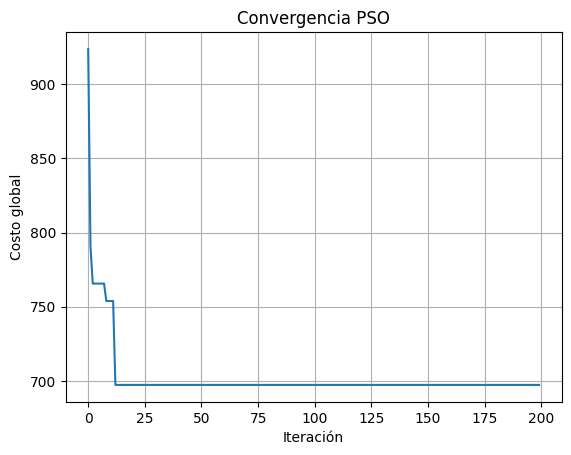

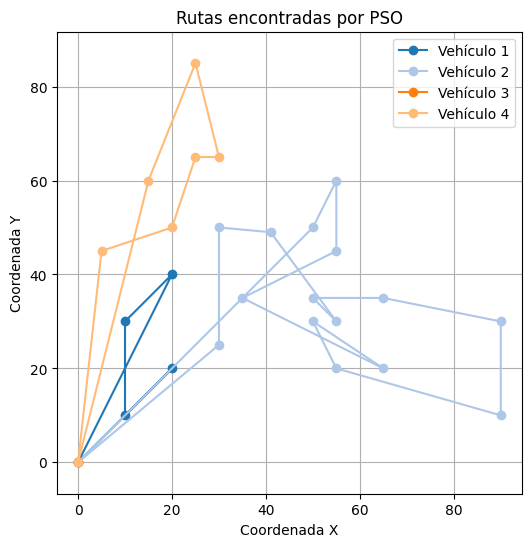

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt


class VRPTW:
    def __init__(self, coordinates, time_windows, demands, vehicle_capacity):
        self.num_customers = len(coordinates)
        self.vehicle_capacity = vehicle_capacity
        self.time_windows = time_windows
        self.demands = demands
        self.coordinates = coordinates
        self.distances = self._compute_distances()

    def _compute_distances(self):
        d = np.zeros((self.num_customers, self.num_customers))
        for i in range(self.num_customers):
            for j in range(self.num_customers):
                x1, y1 = self.coordinates[i]
                x2, y2 = self.coordinates[j]
                d[i, j] = np.hypot(x2 - x1, y2 - y1)
        return d

    def evaluate(self, routes, speed: float = 1000.0) -> float:
        """Devuelve la distancia total si todas las restricciones se cumplen;
        de lo contrario devuelve `inf.

        *speed* convierte la distancia euclídea a tiempo aproximado.
        Si *end_tw* es 999 la ventana se considera abierta.
        """
        total = 0.0
        for route in routes:
            if not route:
                continue
            load = 0
            t = 0  # tiempo actual
            prev = 0  # depósito
            for node in route:
                load += self.demands[node]
                if load > self.vehicle_capacity:
                    return float("inf")

                travel_time = self.distances[prev][node] / speed
                arrival = t + travel_time
                start_tw, end_tw = self.time_windows[node]
                if end_tw == 999:
                    end_tw = 1e9  # ventana abierta
                if arrival > end_tw:
                    return float("inf")
                t = max(arrival, start_tw)
                total += self.distances[prev][node]
                prev = node
            total += self.distances[prev][0]  # regreso al depósito
        return total


class Particle:
    def __init__(self, n_customers: int, n_vehicles: int):
        self.position = np.random.rand(n_customers + 2 * n_vehicles)
        self.velocity = np.zeros_like(self.position)
        self.best_position = self.position.copy()
        self.best_cost = float("inf")


class PSO:
    def __init__(self, vrp: VRPTW, num_particles: int = 30, iterations: int = 200):
        self.vrp = vrp
        self.n_particles = num_particles
        self.iterations = iterations
        self.num_vehicles = 15
        self.particles = [Particle(vrp.num_customers, self.num_vehicles) for _ in range(num_particles)]
        self.global_best_position = None
        self.global_best_cost = float("inf")
        # parámetros PSO
        self.w_start, self.w_end = 0.9, 0.1
        self.cp, self.cg, self.cl, self.cn = 2.0, 2.0, 1.5, 1.5
        self.history = []

    # --- utilidades -----------------------------------------------------
    # ...dentro de la clase PSO...

    def _decode(self, pos):
        n = self.vrp.num_customers
        m = self.num_vehicles
        priority = np.argsort(pos[:n])
        routes = [[] for _ in range(m)]
        ref = pos[n:].reshape(m, 2)
        capacities = [self.vrp.vehicle_capacity] * m

        for cust in priority:
            demand = self.vrp.demands[cust]
            cx, cy = self.vrp.coordinates[cust]
            # Solo vehículos con capacidad suficiente
            feasible = [i for i in range(m) if capacities[i] >= demand]
            if not feasible:
                # Si ningún vehículo puede llevarlo, asigna al primero (solución infactible)
                routes[0].append(cust)
                capacities[0] -= demand
                continue
            # Elige el vehículo más cercano con capacidad suficiente
            d = [np.hypot(cx - ref[i][0], cy - ref[i][1]) if i in feasible else np.inf for i in range(m)]
            idx = int(np.argmin(d))
            routes[idx].append(cust)
            capacities[idx] -= demand
        return [r for r in routes if r]
# ...resto del código...

    # --- PSO principal --------------------------------------------------
    def optimize(self):
        for it in range(self.iterations):
            w = self.w_end + (self.iterations - it) * (self.w_start - self.w_end) / self.iterations
            # evaluación
            for p in self.particles:
                cost = self.vrp.evaluate(self._decode(p.position))
                if cost < p.best_cost:
                    p.best_cost, p.best_position = cost, p.position.copy()
                if cost < self.global_best_cost:
                    self.global_best_cost, self.global_best_position = cost, p.position.copy()
            self.history.append(self.global_best_cost)
            # actualización
            for p in self.particles:
                lbest = random.choice(self.particles).best_position
                nbest = random.choice(self.particles).best_position
                r1, r2, r3, r4 = np.random.rand(4)
                p.velocity = (
                    w * p.velocity
                    + self.cp * r1 * (p.best_position - p.position)
                    + self.cg * r2 * (self.global_best_position - p.position)
                    + self.cl * r3 * (lbest - p.position)
                    + self.cn * r4 * (nbest - p.position)
                )
                p.position += p.velocity
        print(f"Mejor costo: {self.global_best_cost if self.global_best_cost < 1e18 else 'inf'}")

    # --- gráficos -------------------------------------------------------
    def plot_convergence(self):
        plt.plot(self.history)
        plt.title("Convergencia PSO")
        plt.xlabel("Iteración")
        plt.ylabel("Costo global")
        plt.grid(True)
        plt.show()

    def plot_routes(self):
        """
        Dibuja las rutas correspondientes a la mejor partícula global
        encontrada (self.global_best_position).
        """
        if self.global_best_position is None:
            print("No se generó una solución factible.")
            return

        routes = self._decode(self.global_best_position)
        colors = plt.colormaps.get_cmap("tab20")          # hasta 20 colores
        depot_x, depot_y = self.vrp.coordinates[0]

        plt.figure(figsize=(6, 6))
        for i, route in enumerate(routes):
            xs = [depot_x] + [self.vrp.coordinates[n][0] for n in route] + [depot_x]
            ys = [depot_y] + [self.vrp.coordinates[n][1] for n in route] + [depot_y]
            plt.plot(xs, ys, "-o", color=colors(i), label=f"Vehículo {i+1}")

        plt.title("Rutas encontradas por PSO")
        plt.xlabel("Coordenada X")
        plt.ylabel("Coordenada Y")
        plt.legend()
        plt.grid(True)
        plt.axis("equal")          # mantienen escala 1:1
        plt.show()




# Preparación de datos del caso Teherán
# 0 = depósito  (misma convención que Solomon: (x, y, start, end, demanda))
c101_25 = [
    (0.0, 0.0,       0, 1236, 0),      # depósito (idx 0)
    (35.0, 35.0,     0,  230, 10),
    (41.0, 49.0,     0,  230,  7),
    (50.0, 30.0,     0,  230,  7),
    (55.0, 20.0,     0,  230,  7),
    (55.0, 45.0,     0,  230, 10),
    (15.0, 60.0,     0,  230, 12),
    (25.0, 85.0,     0,  230,  5),
    (20.0, 50.0,     0,  230,  9),
    (10.0, 10.0,     0,  230,  3),
    (90.0, 30.0,     0,  230,  1),
    (90.0, 10.0,     0,  230,  1),
    (55.0, 60.0,     0,  230,  2),
    (30.0, 50.0,     0,  230,  4),
    (30.0, 65.0,     0,  230,  4),
    (50.0, 35.0,     0,  230,  8),
    (65.0, 35.0,     0,  230,  8),
    (65.0, 20.0,     0,  230,  2),
    (20.0, 40.0,     0,  230,  4),
    (50.0, 50.0,     0,  230,  4),
    (55.0, 30.0,     0,  230,  6),
    (30.0, 25.0,     0,  230, 10),
    (10.0, 30.0,     0,  230,  2),
    (5.0,  45.0,     0,  230,  6),
    (25.0, 65.0,     0,  230,  6),
    (20.0, 20.0,     0,  230,  8)
]

clientes = c101_25

deposito = [(0.0, 0.0, 0, 999, 0)]

# Mantienes el bloque de relax:
cli_relax = [(x, y, 0, 999, d) for x, y, _, _, d in clientes]
coords       = [(x, y) for x, y, *_ in cli_relax]
time_windows = [(s, e) for *_, s, e, _ in [(x, y, s, e, d) for x, y, s, e, d in cli_relax]]
demands      = [d for *_, d in [(x, y, s, e, d) for x, y, s, e, d in cli_relax]]

vrp  = VRPTW(coords, time_windows, demands, vehicle_capacity=100)  # capacidad relajada
pso  = PSO(vrp, num_particles=30, iterations=200)                  # búsqueda moderada
pso.optimize()
pso.plot_convergence()
pso.plot_routes()        # <-- nueva línea



